# Prediction - Practice

This tutorial demonstrates how to build a predictive model to estimate household living standards in India for 2015 and 2019, using widely available geospatial predictors, such as nightlight intensity, population density, and urbanisation levels. The target variable is drawn from the Demographic and Health Surveys (DHS) and consists of sample-weighted standardised cluster-level observations of households' wealth index.

**Data description:**

| Variable     | Source   | Format | Resolution | Description                      |
|--------------|----------|--------|------------|----------------------------------|
| wealth       | DHS      | GPKG   | –          | Survey-weighted wealth index     |  
| states       | UN       | TIFF   | 1 km       | State identifiers                |
| nightlights  | VIIRS    | TIFF   | 1 km       | Log average nightlight radiance  |
| population   | WorldPop | TIFF   | 1 km       | Log population count             |
| settlements  | GHS SMOD | TIFF   | 1 km       | Recoded: 1=rural, 2=town, 3=city |

**Note:**
The DHS provides cluster-level georeferenced data, but the GPS coordinates randomly shifted for confidentiality. The shift is up to 2 km for "urban" clusters and up to 5 km for "rural" clusters. The UN boundaries include contested areas in a separate file.

In [1]:
# Google Colab
# !pip install geopandas rasterio

In [2]:
# Packages
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shutil
import statsmodels.api as sm
import os
import patsy

from tqdm import tqdm
from scipy import ndimage
from skimage import morphology
from sklearn import linear_model, metrics, model_selection, utils
from urllib import request

# Utilities
def download_data():
    '''Downloads the data folder'''
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/wwz7ezzpnu2iise0007xf/ADqg4NIZWctO4edNuF09XhA?rlkey=kkugufj8acvs3zn84h6qkl532&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def read_raster(srcfile:str, band:int=1, nodata=-9999) -> np.ndarray:
    '''Reads a raster as a numpy array'''
    with rasterio.open(srcfile) as src:
        raster = src.read(band).astype(float)  # ensure float for NaNs
    raster = np.where(raster == nodata, np.nan, raster)
    return raster

def write_raster(array:np.ndarray, profile, dstfile:str, update:dict=None) -> None:
    '''Writes a numpy array as a raster'''
    if array.ndim == 2:
        array = np.expand_dims(array, axis=0)
    profile = rasterio.open(profile).profile
    if update is not None:
        profile.update(**update)
    with rasterio.open(fp=dstfile, mode='w', **profile) as raster:
        raster.write(array)
        raster.close()

def plot_raster(array: np.ndarray, title:str='', cmap:str='magma') -> None:
    '''Plots a raster array'''
    if array.ndim > 2:
        array = array[0]
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(array, cmap=cmap)
    fig.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=15)
    ax.axis('off')
    plt.show()
    plt.close()

def plot_geopandas(gdf:gpd.GeoDataFrame, column:str=None, title:str='', cmap:str='magma', markersize:int=1) -> None:
    '''Plots a GeoDataFrame'''
    fig, ax = plt.subplots(figsize=(5, 5))
    gdf.plot(column=column, cmap=cmap, markersize=markersize, legend=True, ax=ax)
    ax.set_title(title, fontsize=15)
    ax.axis('off')
    plt.show()
    plt.close()

In [3]:
# Execute on first run
download_data()

1. **Load data**

- Load the `wealth` dataset for year 2015 using `gpd.read_file`.
- Load the `nightlights`, `population` and `settlements` rasters for year 2015 using the provided `read_raster` function.

In [4]:
wealth      = gpd.read_file('wealth_india_2015.gpkg')
nightlights = read_raster('nightlights_india_2015.tif')
population  = read_raster('population_india_2015.tif')
settlements = read_raster('settlements_india_2015.tif')


2. **Descriptive statistics: Response**

- Visualise the first rows of the `wealth_index` dataset using the `head` method.
- Compute descriptive statistics for the `wealth_index` variable using the `describe` method.
- Compute frequencies for the categorical variables `state` and `urban_cluster` using the `value_counts` method.
- Visualise the cluster locations using the provided `plot_geopandas` function.

In [5]:
wealth.head()

,cluster_id,n_households,urban_cluster,state,state_id,wealth_index,geometry
0,20001,22,False,andhra pradesh,1,0.342995,POINT (3753394.954 2962623.739)
1,20002,20,False,andhra pradesh,1,0.085952,POINT (4105449.062 3182596.305)
2,20003,21,False,andhra pradesh,1,-0.200646,POINT (3700895.863 3054626.045)
3,20004,22,False,andhra pradesh,1,-0.992903,POINT (4263318.084 3394973.504)
4,20005,22,False,andhra pradesh,1,0.314816,POINT (4209728.123 3195039.843)


In [6]:
wealth['wealth_index'].describe()

count    27944.000000
mean         0.001641
std          0.793144
min         -1.792713
25%         -0.628779
50%         -0.082156
75%          0.613096
max          2.238090
Name: wealth_index, dtype: float64

In [7]:
print(wealth['state'].value_counts())

state
uttar pradesh                         3624
madhya pradesh                        2412
bihar                                 1661
rajasthan                             1630
odisha                                1406
maharashtra                           1328
jharkhand                             1240
tamil nadu                            1212
assam                                 1137
karnataka                             1136
gujarat                                973
chhattisgarh                           937
haryana                                797
punjab                                 756
jammu & kashmir                        748
uttarakhand                            724
west bengal                            713
arunachal pradesh                      702
manipur                                549
mizoram                                533
nagaland                               530
kerala                                 526
andhra pradesh                         497
himac

In [8]:
print(wealth['urban_cluster'].value_counts())

urban_cluster
False    19699
True      8245
Name: count, dtype: int64


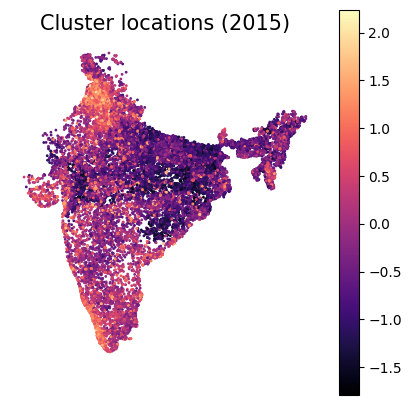

In [9]:
plot_geopandas(wealth, column='wealth_index', title='Cluster locations (2015)')


3. **Descriptive statistics: Inputs**

- Visualise the `nightlights`, `population` and `settlements` rasters using the provided `plot_raster` function.
- Check the dimensions of the `nightlights`, `population` and `settlements` using the `shape` method and compute descriptive statistics.

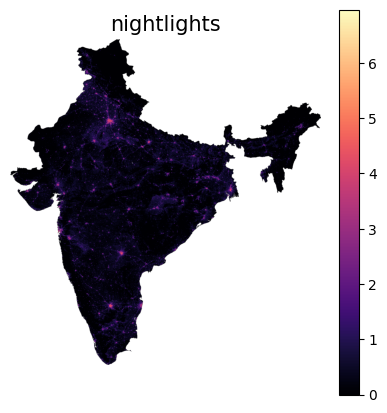

In [10]:
plot_raster(nightlights, title="nightlights")


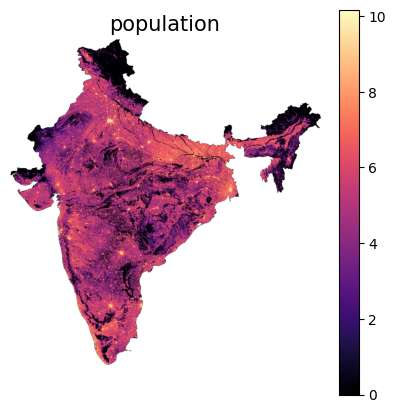

In [11]:
plot_raster(population, title="population")


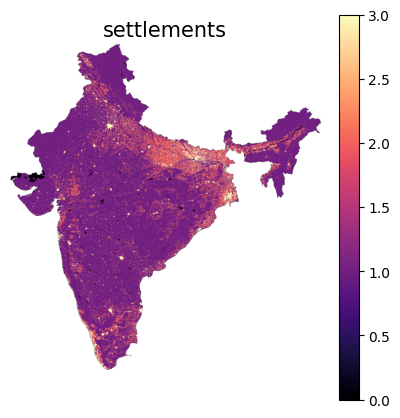

In [12]:
plot_raster(settlements, title="settlements")

In [13]:
for name, arr in [('nightlights', nightlights), ('population', population), ('settlements', settlements)]:
    print(f"\n{name} - shape: {arr.shape}")
    print(pd.Series(arr.flatten()).describe())



nightlights - shape: (3008, 2861)
count    3.037080e+06
mean     2.930668e-01
std      4.431562e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.190332e-01
75%      4.408289e-01
max      6.966489e+00
dtype: float64

population - shape: (3008, 2861)
count    3.037080e+06
mean     4.074776e+00
std      2.418420e+00
min      0.000000e+00
25%      2.619599e+00
50%      4.836522e+00
75%      5.830094e+00
max      1.017424e+01
dtype: float64

settlements - shape: (3008, 2861)
count    3.037080e+06
mean     1.199494e+00
std      5.006360e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
dtype: float64


4. **Extracting raster values (answer provided)**

This code extracts raster values for `nightlights`, `population`, and `settlements` at the cluster coordinates and appends them to the dataset. Because DHS coordinates are randomly displaced (up to 2 km in urban areas and 5 km in rural areas), the code computes average values within 2 km and 5 km buffers, respectively. For simplicity, the `settlements` raster is converted into a binary variable, `urban_area`. For the remainder of this exercise, use the computed `dataset` containing the relevant variables.

In [14]:
# Urban area binary variable
urban_areas = np.where(np.isnan(settlements), np.nan, settlements == 3)

# Extracts affine transform mapping geographic coordinates to pixel coordinates
with rasterio.open('grid_india.tif') as src:
    transform = src.transform

def sample_array(array:np.ndarray, gdf:gpd.GeoDataFrame, transform:rasterio.Affine) -> np.ndarray:
    '''Samples raster values at point locations'''
    cols, rows = np.round([~transform * (coord.x, coord.y) for coord in gdf.geometry]).astype(int).T
    mask   = ((rows >= 0) & (rows < array.shape[0]) & (cols >= 0) & (cols < array.shape[1]))
    values = np.full(len(rows), np.nan)
    values[mask] = array[rows[mask], cols[mask]]
    return values

dataset = wealth.drop(columns=['n_households', 'urban_cluster', 'geometry'])

'''
# Extracts raster values without spatial smoothing
for var, name in zip([nightlights, population, urban_areas], ['nightlights', 'population', 'urban_areas']):
    dataset[name] = sample_array(array=var, gdf=wealth, transform=transform)
'''

# Extracts raster values with spatial smoothing
for var, name in zip([nightlights, population, urban_areas], ['nightlights', 'population', 'urban_areas']):
    smooth = dict()
    for dist in [2, 5]:
        kernel = morphology.disk(dist)
        values = ndimage.convolve(input=np.nan_to_num(var, nan=0.0), weights=kernel / kernel.sum(), mode='constant', cval=0.0)
        values = sample_array(array=values, gdf=wealth, transform=transform)
        smooth[f'{dist}k'] = values
    dataset[name] = np.where(wealth['urban_cluster'], smooth['2k'], smooth['5k'])

dataset['urban_areas'] = dataset['urban_areas'] > 0.5
del var, name, smooth, dist, kernel, values

5. **Training and test samples** 

Randomly partition the observations into a training sample (75%) and a test sample (25%) using `model_selection.train_test_split`. Specify a seed using the `random_state` argument to make your results reproductible.

In [15]:
X = dataset.drop(columns=['wealth_index'])
y = dataset['wealth_index']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.25, random_state=2003
)


6. **Estimation**

- Fit a linear model to the training sample using `linear_model.LinearRegression()`. 
- Extract the estimated parameters using the `coef_` method of the model.
- Interpret the sign, magnitude and significance of estimated coefficients. 

**Note:** For econometrics-style regression tables, you can also use the `statsmodels` package. Alternatively, you can use `sklearn.ensembles.RandomForestRegressor`.

In [16]:
X_train_clean = pd.get_dummies(X_train, columns=['state'], drop_first=True).astype(float)
X_test_clean  = pd.get_dummies(X_test,  columns=['state'], drop_first=True).astype(float)

X_train_sm = sm.add_constant(X_train_clean)
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())



                            OLS Regression Results                            
Dep. Variable:           wealth_index   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     1014.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        14:28:16   Log-Likelihood:                -14055.
No. Observations:               20958   AIC:                         2.819e+04
Df Residuals:                   20920   BIC:                         2.849e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

The model describes around 64.2% of the variance. From the independent variables, only urban_areas and state_chandigarh are insignificant. 

**7. Model performance**

- Compute the predicted `wealth_index` for the training and the test samples.
- Assess the model's performance on each sample using `metrics.mean_squared_error`.
- Compute the cross-validated error using `model_selection.cross_validate` with 100 folds and the scoring method `neg_mean_squared_error`.

In [17]:
# Predictions
y_pred_train = ols.fittedvalues
y_pred_test  = ols.predict(sm.add_constant(X_test_clean))


In [18]:
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
mse_test  = metrics.mean_squared_error(y_test,  y_pred_test)
print(f"Train MSE: {mse_train:.4f}")
print(f"Test MSE:  {mse_test:.4f}")


Train MSE: 0.2239
Test MSE:  0.2231


In [19]:
cv_model  = linear_model.LinearRegression()
cv_results = model_selection.cross_validate(
    cv_model, X_train_clean, y_train,
    cv=100, scoring='neg_mean_squared_error'
)
cv_mse = -cv_results['test_score'].mean()
print(f"CV MSE (100 folds): {cv_mse:.4f}")


CV MSE (100 folds): 0.2247


**8. Prediction**

- Create a `dataset` containing the predictors for all observations.
- Using your estimated model, predict the `wealth_index` for the entire country.
- Visualise the resuts using the provided `plot_raster` function.

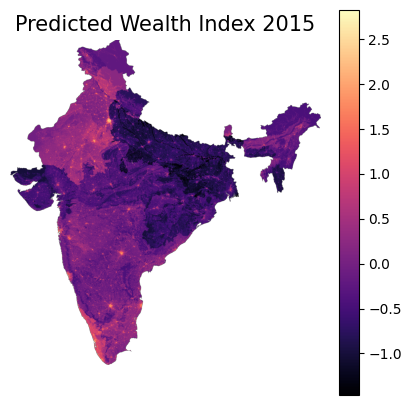

In [22]:
# Load states raster and derive urban_areas for full grid
states_raster    = read_raster('states_india.tif')
urban_areas_full = np.where(np.isnan(settlements), np.nan, settlements == 3)

# Build state code → name mapping using cluster locations
state_codes = wealth[['state']].copy()
state_codes['code'] = sample_array(array=states_raster, gdf=wealth, transform=transform)
code_to_name = state_codes.drop_duplicates('code').set_index('code')['state'].to_dict()

# Flatten all rasters into a DataFrame
shape = nightlights.shape
grid = pd.DataFrame({
    'nightlights': nightlights.flatten(),
    'population':  population.flatten(),
    'urban_areas': urban_areas_full.flatten(),
    'state':       pd.Series(states_raster.flatten()).map(code_to_name),
})

# Drop NaN pixels
valid_mask  = ~grid.isnull().any(axis=1)
grid_valid  = grid[valid_mask].copy()

# Encode state dummies to match training columns
grid_encoded = pd.get_dummies(grid_valid, columns=['state'], drop_first=True).astype(float)

# Add any state columns present in training but missing in grid (set to 0)
for col in X_train_clean.columns:
    if col not in grid_encoded.columns:
        grid_encoded[col] = 0

grid_sm = sm.add_constant(grid_encoded[X_train_clean.columns], has_constant='add')

# Predict
predictions = ols.predict(grid_sm)

# Reshape back to raster and plot
pred_raster = np.full(shape[0] * shape[1], np.nan)
pred_raster[valid_mask] = predictions
pred_raster = pred_raster.reshape(shape)

plot_raster(pred_raster, title='Predicted Wealth Index 2015')

**9. Modelling approach**

- Comment on the relevance of the model choice.
- Which other predictors would you use?

**BONUS (intermediate)**. Replicate the analysis by modelling changes between 2015 and 2020. Note that the `wealth_index` variable is standardised separately for each wave and therefore not directly comparable across waves.

Since wealth is standardised separately per wave (not directly comparable), the approach is to pool both years with a year fixed effect.

In [23]:
# Load 2019 data
wealth_19=gpd.read_file('wealth_india_2019.gpkg')
nightlights_19 = read_raster('nightlights_india_2019.tif')
population_19  = read_raster('population_india_2019.tif')
settlements_19 = read_raster('settlements_india_2019.tif')

# Extract raster values at cluster locations (same as cell 4)
urban_areas_19 = np.where(np.isnan(settlements_19), np.nan, settlements_19 == 3)

dataset_19 = wealth_19.drop(columns=['n_households', 'urban_cluster', 'geometry'])

for var, name in zip([nightlights_19, population_19, urban_areas_19], ['nightlights', 'population', 'urban_areas']):
    smooth = dict()
    for dist in [2, 5]:
        kernel = morphology.disk(dist)
        values = ndimage.convolve(input=np.nan_to_num(var, nan=0.0), weights=kernel / kernel.sum(), mode='constant', cval=0.0)
        values = sample_array(array=values, gdf=wealth_19, transform=transform)
        smooth[f'{dist}k'] = values
    dataset_19[name] = np.where(wealth_19['urban_cluster'], smooth['2k'], smooth['5k'])

dataset_19['urban_areas'] = dataset_19['urban_areas'] > 0.5


In [24]:
dataset_15 = dataset.copy()
dataset_15['year'] = 0   # 2015 = reference
dataset_19['year'] = 1   # 2019

pooled = pd.concat([dataset_15, dataset_19], ignore_index=True)


In [25]:
X_pool = pooled.drop(columns=['wealth_index'])
y_pool = pooled['wealth_index']

X_pool_enc = pd.get_dummies(X_pool, columns=['state'], drop_first=True).astype(float)

X_pool_sm = sm.add_constant(X_pool_enc)
ols_pooled = sm.OLS(y_pool, X_pool_sm).fit()
print(ols_pooled.summary())


                            OLS Regression Results                            
Dep. Variable:           wealth_index   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     872.9
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        14:39:48   Log-Likelihood:            -1.7281e+05
No. Observations:               58999   AIC:                         3.457e+05
Df Residuals:                   58960   BIC:                         3.461e+05
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

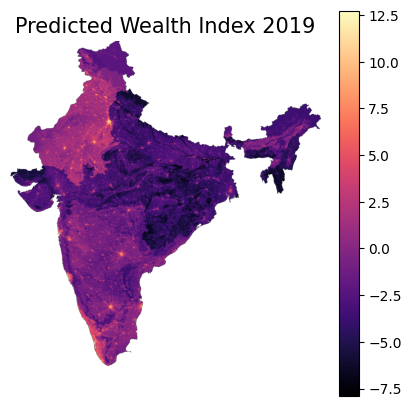

In [26]:
# Build 2019 grid (same as task 8)
urban_areas_full_19 = np.where(np.isnan(settlements_19), np.nan, settlements_19 == 3)

grid_19 = pd.DataFrame({
    'nightlights': nightlights_19.flatten(),
    'population':  population_19.flatten(),
    'urban_areas': urban_areas_full_19.flatten(),
    'state':       pd.Series(states_raster.flatten()).map(code_to_name),
    'year':        1,
})

valid_mask_19 = ~grid_19.isnull().any(axis=1)
grid_19_valid = grid_19[valid_mask_19].copy()

grid_19_enc = pd.get_dummies(grid_19_valid, columns=['state'], drop_first=True).astype(float)
for col in X_pool_enc.columns:
    if col not in grid_19_enc.columns:
        grid_19_enc[col] = 0

grid_19_sm = sm.add_constant(grid_19_enc[X_pool_enc.columns], has_constant='add')
pred_19 = ols_pooled.predict(grid_19_sm)

pred_raster_19 = np.full(nightlights_19.shape[0] * nightlights_19.shape[1], np.nan)
pred_raster_19[valid_mask_19] = pred_19
pred_raster_19 = pred_raster_19.reshape(nightlights_19.shape)

plot_raster(pred_raster_19, title='Predicted Wealth Index 2019')


**BONUS (advanced)**. Use `utils.resample` to generate 1,000 bootstrap samples (with replacement), each of the same size as the original dataset. Compute the 95% confidence and prediction intervals. Plot the results and comment on the model's predictive performance.

100%|██████████| 1000/1000 [00:10<00:00, 97.37it/s]


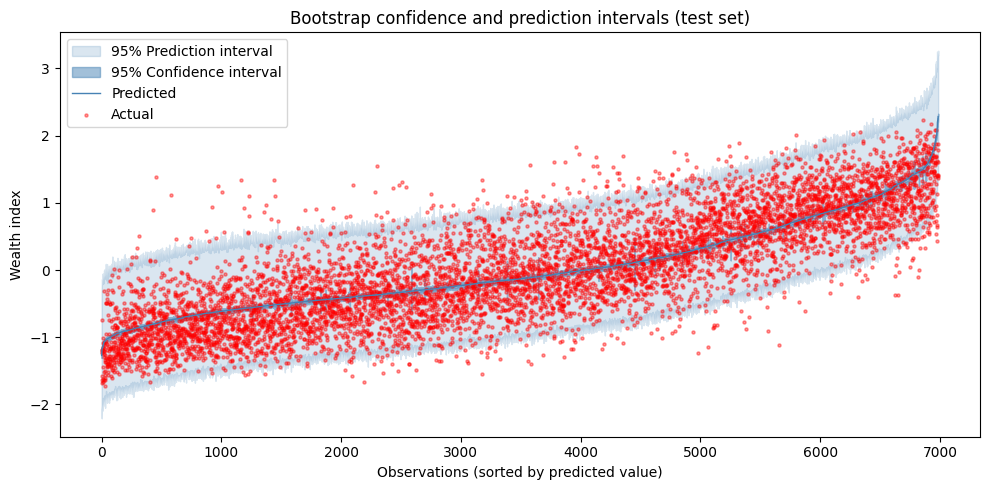

In [27]:
n_bootstrap = 1000
preds_boot = np.zeros((n_bootstrap, len(X_test_clean)))
preds_pi   = np.zeros((n_bootstrap, len(X_test_clean)))

boot_model = linear_model.LinearRegression()
np.random.seed(42)

for i in tqdm(range(n_bootstrap)):
    # Resample training data with replacement
    X_b, y_b = utils.resample(X_train_clean, y_train, replace=True, random_state=i)
    boot_model.fit(X_b, y_b)
    
    # Predictions on test set
    y_pred_b = boot_model.predict(X_test_clean)
    preds_boot[i] = y_pred_b
    
    # Add random residual from bootstrap fit for prediction interval
    resid_b = y_b - boot_model.predict(X_b)
    preds_pi[i] = y_pred_b + np.random.choice(resid_b, size=len(X_test_clean), replace=True)

# Point estimate and intervals
y_pred_mean = preds_boot.mean(axis=0)
ci_lower = np.percentile(preds_boot, 2.5,  axis=0)
ci_upper = np.percentile(preds_boot, 97.5, axis=0)
pi_lower = np.percentile(preds_pi,   2.5,  axis=0)
pi_upper = np.percentile(preds_pi,   97.5, axis=0)

# Sort by predicted value for a cleaner plot
idx = np.argsort(y_pred_mean)
x   = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x, pi_lower[idx], pi_upper[idx], alpha=0.2, color='steelblue', label='95% Prediction interval')
ax.fill_between(x, ci_lower[idx], ci_upper[idx], alpha=0.5, color='steelblue', label='95% Confidence interval')
ax.plot(x, y_pred_mean[idx], color='steelblue', linewidth=1, label='Predicted')
ax.scatter(x, np.array(y_test)[idx], s=5, color='red', alpha=0.4, label='Actual')
ax.set_xlabel('Observations (sorted by predicted value)')
ax.set_ylabel('Wealth index')
ax.set_title('Bootstrap confidence and prediction intervals (test set)')
ax.legend()
plt.tight_layout()
plt.show()
